In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('../data/nutrient_data.csv', encoding='latin1')

In [4]:
df.head()

,age,bmi,hb,dietScore,protein_g,calcium_mg,iron_mg,deficiency_type
0,24,28.303899,13.429708,6,97.527986,937.831028,15.444138,0
1,37,27.293521,8.792475,3,61.619346,687.883583,3.628108,3
2,32,23.288633,13.617697,10,32.601889,990.251902,7.804906,2
3,28,17.246897,8.958060,6,74.317410,469.039778,24.851479,3
4,25,31.608746,10.886758,4,70.477810,1057.352674,21.821742,0


In [5]:
df.isna().sum()

age                0
bmi                0
hb                 0
dietScore          0
protein_g          0
calcium_mg         0
iron_mg            0
deficiency_type    0
dtype: int64

In [6]:
X = df.drop('deficiency_type', axis=1)

In [7]:
y = df['deficiency_type']

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [10]:
from sklearn.ensemble import RandomForestClassifier

In [11]:
rfc = RandomForestClassifier(random_state=42)

In [12]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "criterion": ["gini", "entropy"]
}

In [13]:
from sklearn.model_selection import GridSearchCV

In [14]:
gridRfc  = GridSearchCV(
    rfc,
    param_grid,
    cv = 5,
    scoring='accuracy',
    n_jobs=-1
)

In [15]:
gridRfc.fit(X_train, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,300


In [16]:
best_rfc_model = gridRfc.best_estimator_

In [17]:
print(gridRfc.best_estimator_)

RandomForestClassifier(n_estimators=300, random_state=42)


In [18]:
y_pred = best_rfc_model.predict(X_test)

In [19]:
from sklearn.metrics import accuracy_score, classification_report

In [20]:
accuracy_score(y_test, y_pred)

0.912

In [21]:
print(df["deficiency_type"].value_counts())

deficiency_type
0    841
2    404
1    325
3    313
4    117
Name: count, dtype: int64


In [23]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.98      0.95       203
           1       0.92      0.91      0.92        89
           2       0.85      0.92      0.88       100
           3       0.96      0.89      0.92        74
           4       0.90      0.56      0.69        34

    accuracy                           0.91       500
   macro avg       0.91      0.85      0.87       500
weighted avg       0.91      0.91      0.91       500



In [24]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

print(report_df)

              precision    recall  f1-score  support
0              0.925234  0.975369  0.949640  203.000
1              0.920455  0.910112  0.915254   89.000
2              0.851852  0.920000  0.884615  100.000
3              0.956522  0.891892  0.923077   74.000
4              0.904762  0.558824  0.690909   34.000
accuracy       0.912000  0.912000  0.912000    0.912
macro avg      0.911765  0.851239  0.872699  500.000
weighted avg   0.912945  0.912000  0.908989  500.000


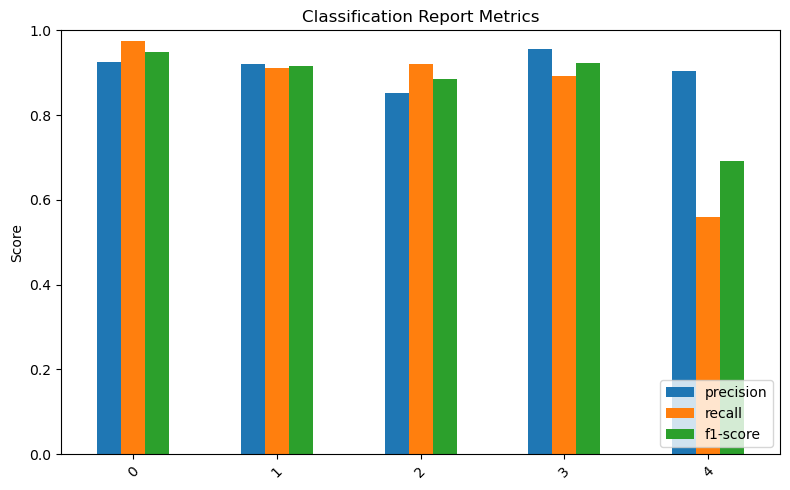

In [25]:
import matplotlib.pyplot as plt

metrics = report_df.iloc[:-3][['precision', 'recall', 'f1-score']]

metrics.plot(kind='bar', figsize=(8,5))
plt.title("Classification Report Metrics")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

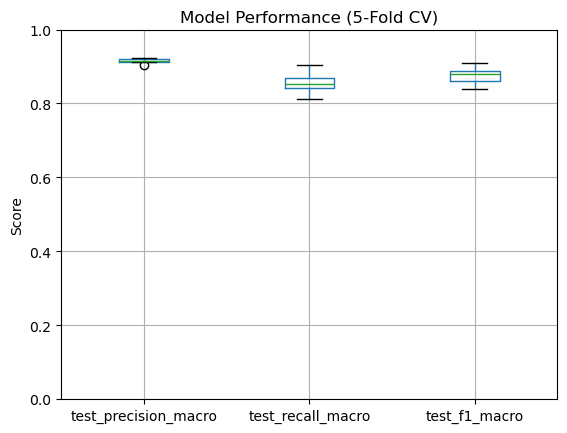

In [27]:
from sklearn.model_selection import cross_validate
import pandas as pd
import matplotlib.pyplot as plt

scoring = ['precision_macro', 'recall_macro', 'f1_macro']

cv_results = cross_validate(best_rfc_model, X, y, cv=5, scoring=scoring)

cv_df = pd.DataFrame(cv_results)

cv_df[['test_precision_macro', 
       'test_recall_macro', 
       'test_f1_macro']].boxplot()

plt.title("Model Performance (5-Fold CV)")
plt.ylabel("Score")
plt.ylim(0,1)
plt.show()

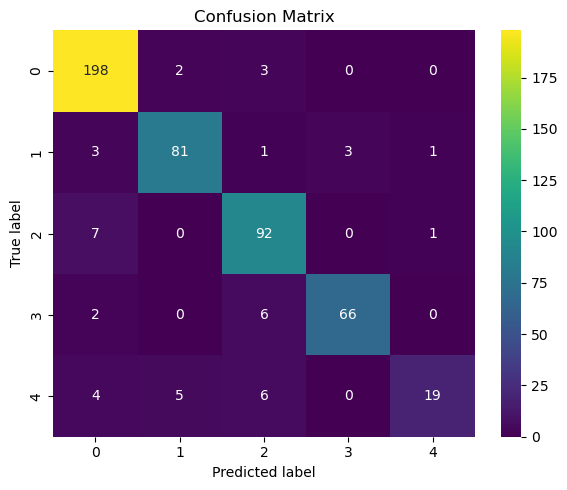

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='viridis',   # same green-yellow style
            cbar=True)

plt.title("Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()